<a href="https://colab.research.google.com/github/carlos-000-carlos/Challenge_3-TelecomX_parte2_BR-Cabral/blob/main/TelecomX2_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

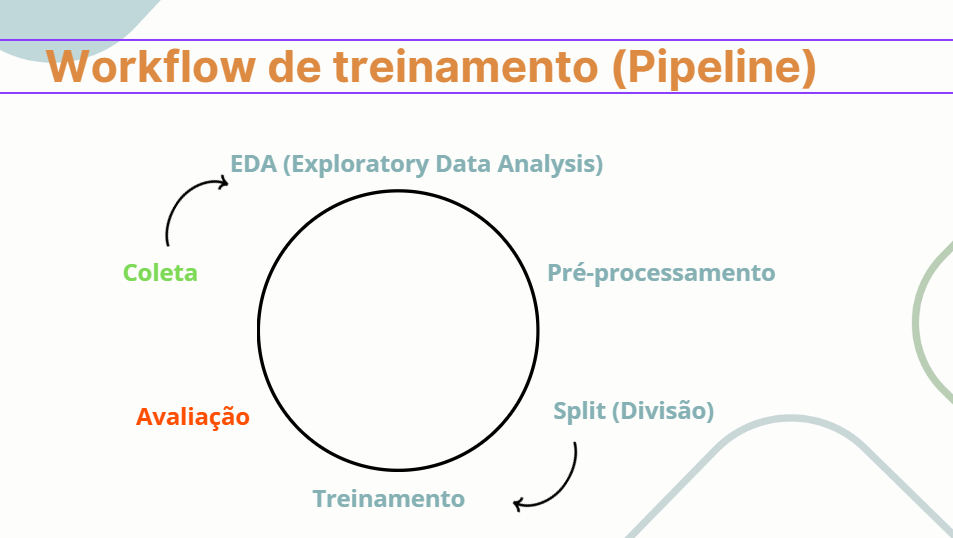

## Etapa 1 - 📌 Extração (Coleta dos Dados):

In [29]:
# import das bibliotecas mais comuns a serem usadas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [30]:
# Extração dos dados através do link do arquivo de dados que já está no GitHub
dados = pd.read_csv('https://raw.githubusercontent.com/carlos-000-carlos/Challenge_3-TelecomX_parte2_BR-Cabral/refs/heads/main/dados_tratados.csv')
dados.head(1000)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1447-GIQMR,Yes,Male,No,Yes,No,1,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,2.31,69.15,69.15
996,1447-PJGGA,Yes,Female,No,No,No,57,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Two year,Yes,Electronic check,3.18,95.25,5464.65
997,1448-CYWKC,No,Female,No,Yes,Yes,58,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),3.51,105.20,6225.40
998,1448-PWKYE,Yes,Male,No,Yes,Yes,1,Yes,No,Fiber optic,...,No,No,No,Yes,Month-to-month,No,Electronic check,2.67,80.00,80.00


In [31]:
# Explorando as colunas que temos no nosso DataFrame
dados.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [32]:
# Explorando as colunas e visualizando seus tipos de dados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## Etapa 2 - 🛠️ Pré-Processamento:


Passo 1 - ❌ Remoção das Colunas Irrelevantes

In [33]:
# Removendo a coluna "CustomerID"
dados = dados.drop(columns = ['CustomerID'])

In [35]:
# Criamos uma lista com os nomes das colunas do Dataframe
colunas = list(dados.columns)
colunas


['Churn',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'ChargesDaily',
 'ChargesMonthly',
 'ChargesTotal']

In [36]:
# Aplicando o método "unique" a várias colunas de uma só vez
valores_unicos = dados[colunas].apply(pd.Series.unique)
print(valores_unicos)

Churn                                                       [No, Yes]
Gender                                                 [Female, Male]
SeniorCitizen                                               [No, Yes]
Partner                                                     [Yes, No]
Dependents                                                  [Yes, No]
Tenure              [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
PhoneService                                                [Yes, No]
MultipleLines                                               [No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                                              [No, Yes]
OnlineBackup                                                [Yes, No]
DeviceProtection                                            [No, Yes]
TechSupport                                                 [Yes, No]
StreamingTV                                                 [Yes, No]
StreamingMovies     

In [40]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


Passo 2 - 🖇 Agrupamento de "No" com "No internet service"

In [43]:
# Colunas escolhidas para agrupar
colunas_para_agrupar = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for nome in colunas_para_agrupar:
  dados[nome] = dados[nome].replace('No internet service', 'No')

In [45]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


Passo 3 - ❓Ø❓ Verificação de Valores Nulos

In [46]:
# Usamos a função "isnull"
dados.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Etapa 3 - 📊 EDA (Análise Exploratória dos Dados)

Passo 1 - 🔀 Correlação entre Variáveis Numéricas

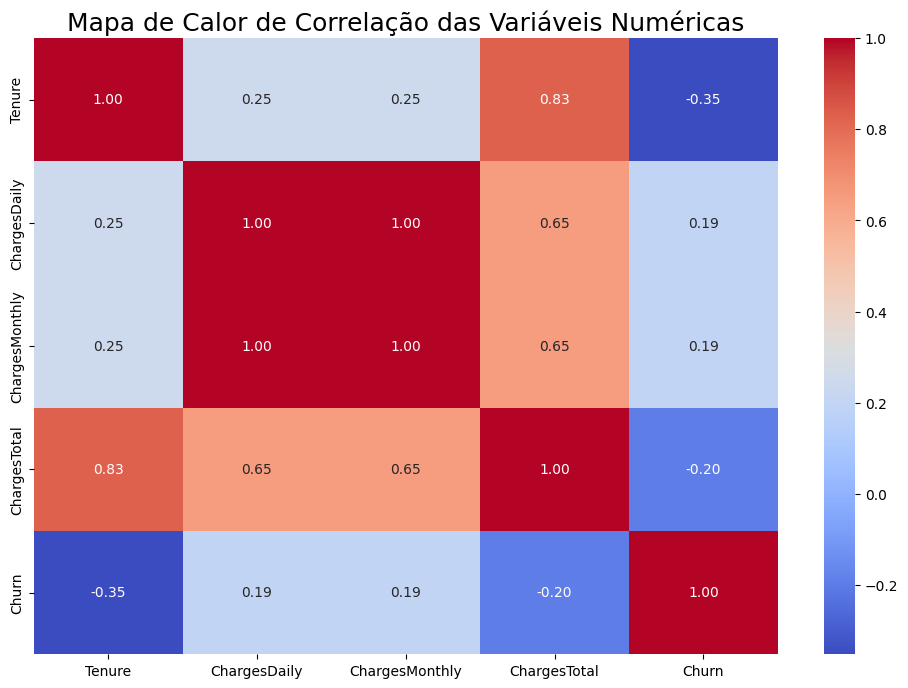

In [49]:
# Selecionamos somente variáveis numéricas
df_variaveis_numericas = dados.select_dtypes(include = ['int64', 'float64'])

# Convertemos a variável "Churn" para valores numéricos
df_variaveis_numericas['Churn'] = dados['Churn'].map({'Yes' : 1, 'No' : 0})

# Aplicamos a matriz de correlação
corr_matrix = df_variaveis_numericas.corr()

# Plotagem da visualização
plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True,
            cmap = 'coolwarm', fmt = ".2f")
plt.title("Mapa de Calor de Correlação das Variáveis Numéricas",
          fontsize = 18)
plt.show()

In [50]:
# Retirando as colunas "ChargesDaily" e "ChargesTotal", pois não devem entrar na correlação
dados = dados.drop(columns = ['ChargesDaily', 'ChargesTotal'])

In [51]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


Passo 2 - 📊📈 Análise de Evasão por Categoria (Variáveis Categóricas)

 ⣏⣹ 👁️‍🗨️ Seleção de Variáveis Categóricas

In [53]:
# Selecionando apenas colunas categóricas
colunas_categoricas = dados.select_dtypes(include = ['object']).columns
colunas_categoricas = colunas_categoricas.drop('Churn')

𝄜 % Tabela de Proporção de Evasão X Categorias

In [65]:
# Laço de repetição para criar as tabelas de evasão dentro de cada categoria
for column in colunas_categoricas:
  print(f'\n\n 🔢 ❯❯❯❯ Análise da Evasão X {column}')
  display(round(pd.crosstab(dados[column], dados['Churn'],
                      normalize = 'index') * 100, 2))



 🔢 ❯❯❯❯ Análise da Evasão X Gender


Churn,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16




 🔢 ❯❯❯❯ Análise da Evasão X SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68




 🔢 ❯❯❯❯ Análise da Evasão X Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83




 🔢 ❯❯❯❯ Análise da Evasão X PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57




 🔢 ❯❯❯❯ Análise da Evasão X PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


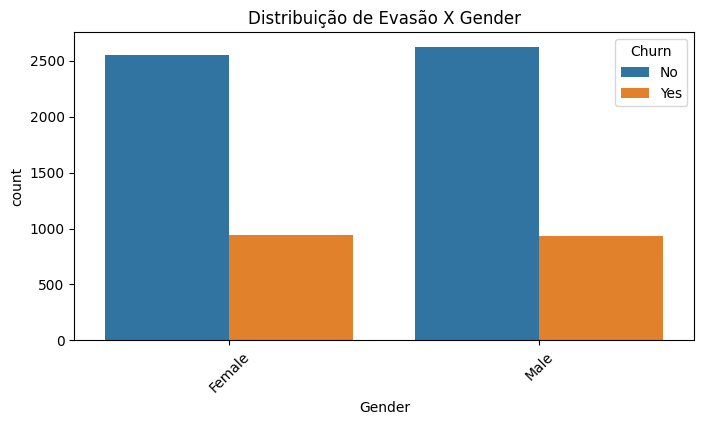

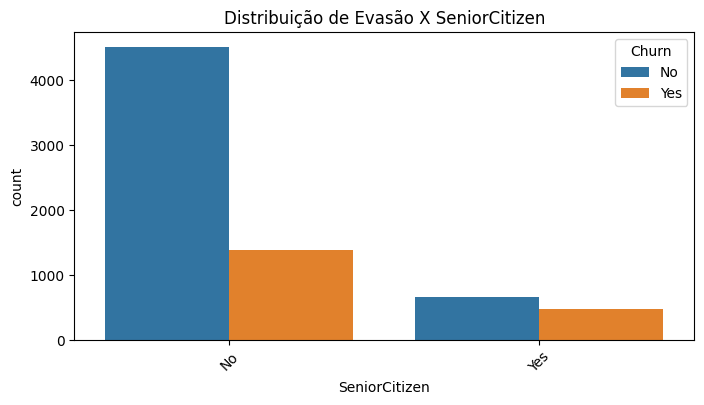

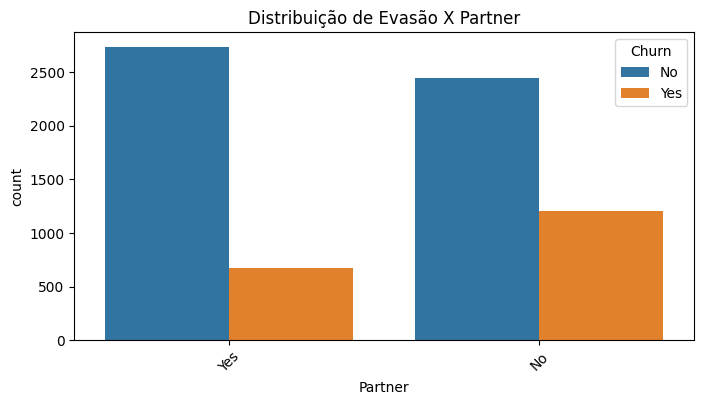

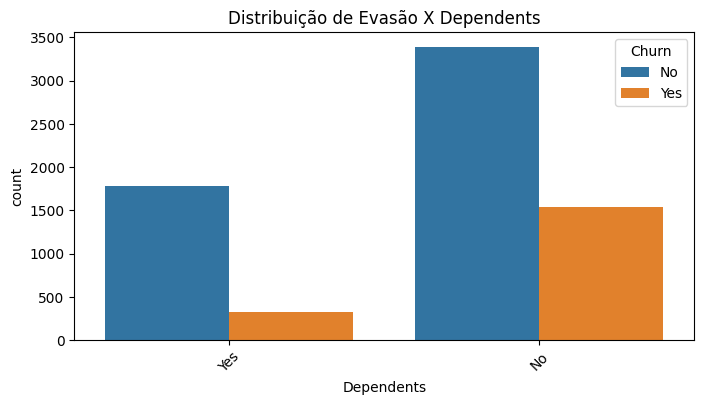

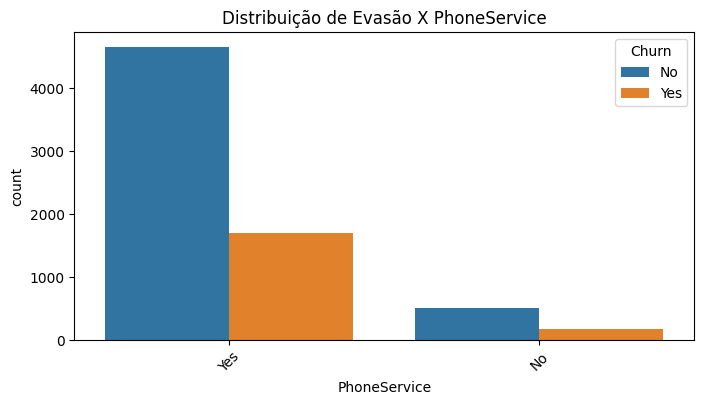

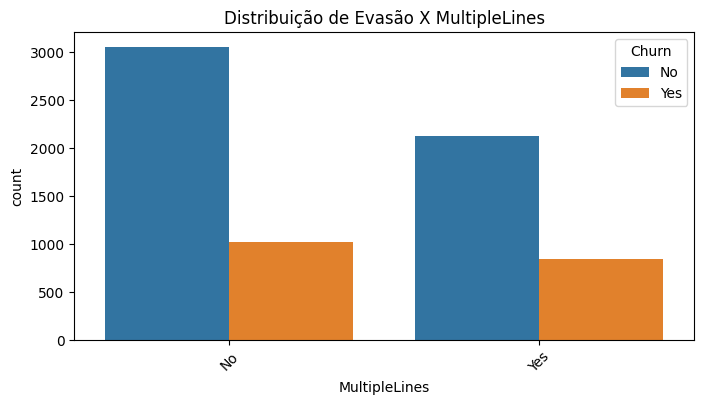

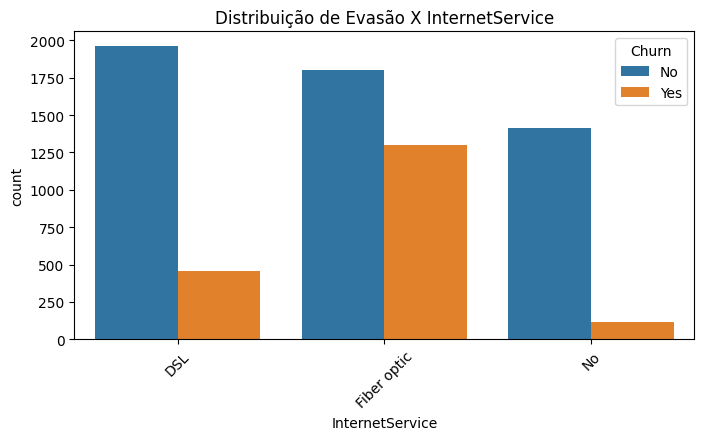

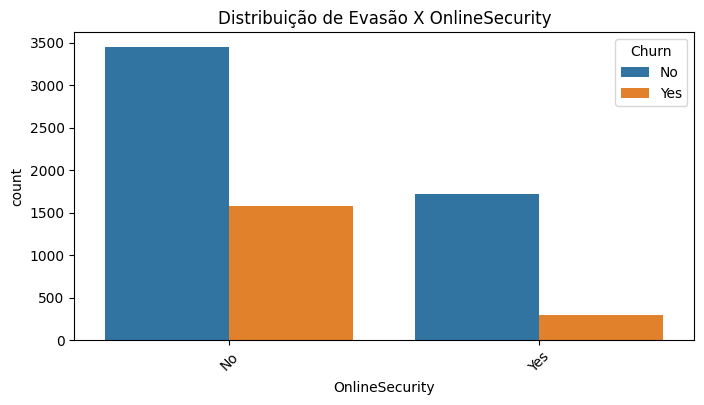

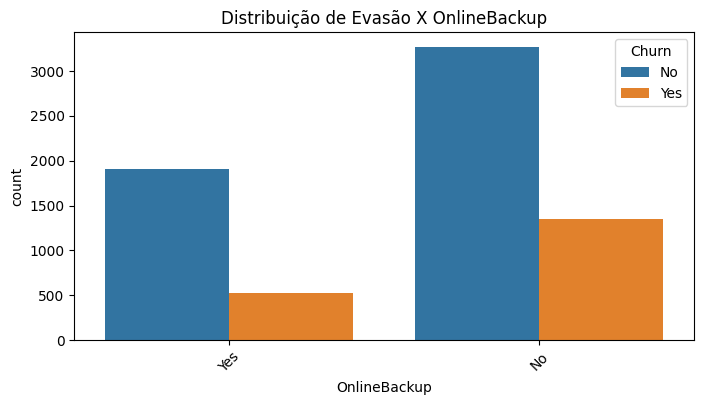

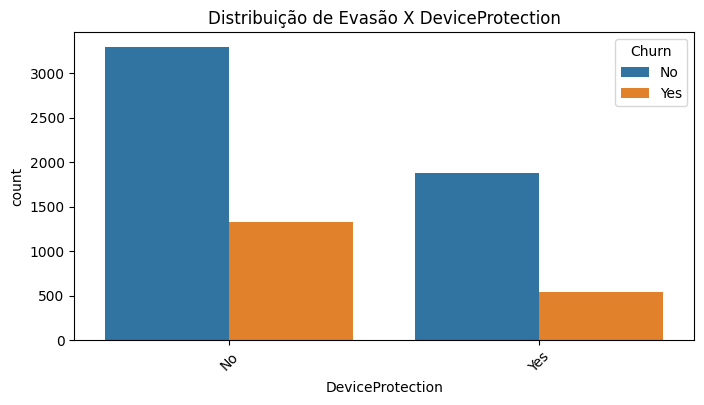

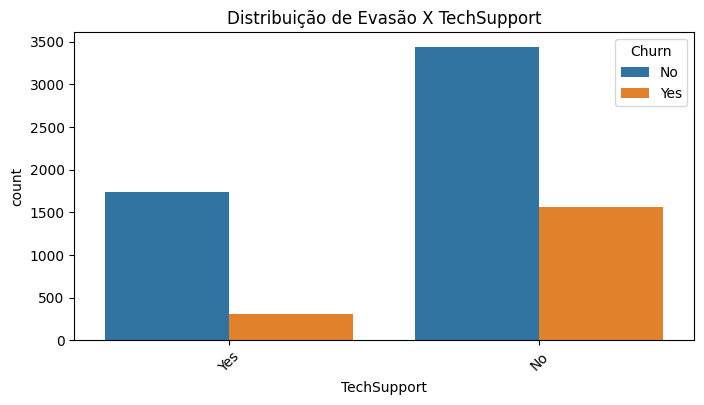

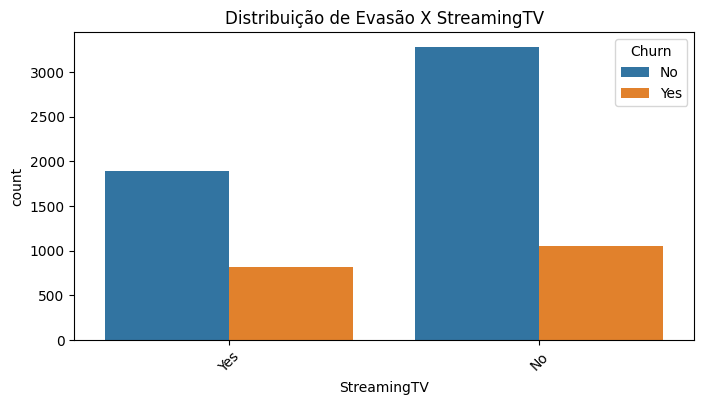

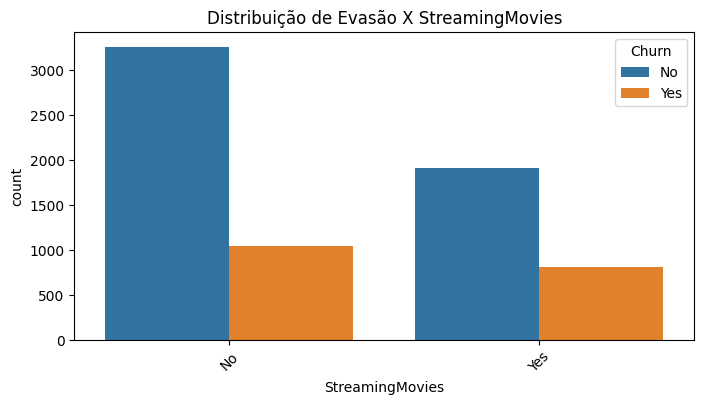

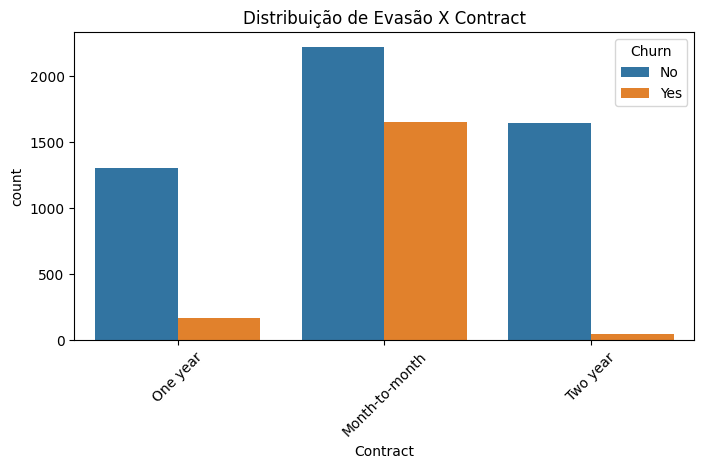

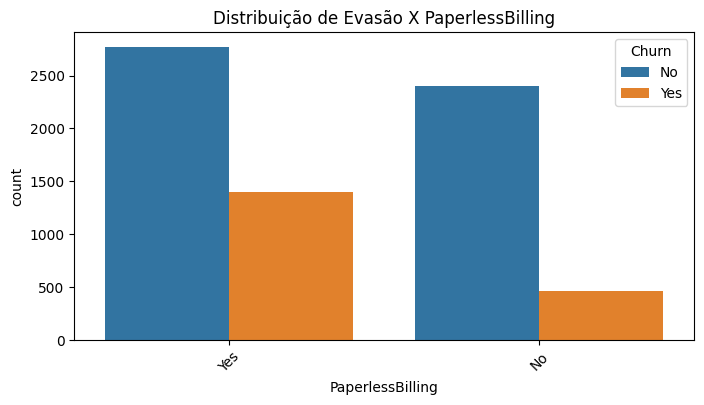

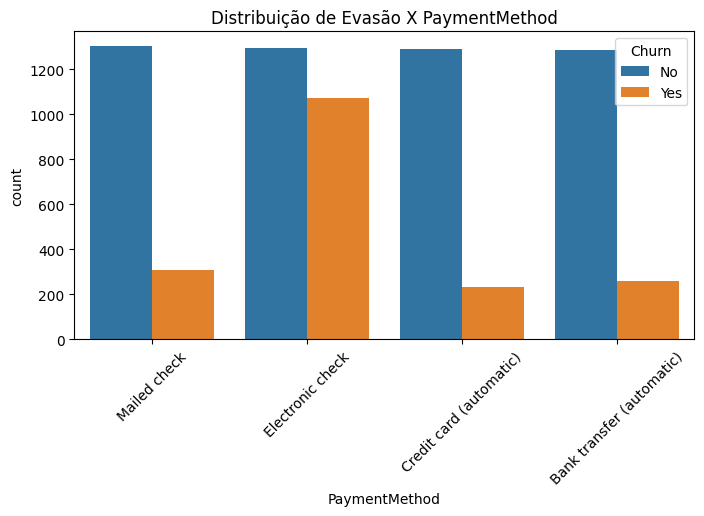

In [67]:
# Laço de repetição para criar os gráficos de evasão dentro de cada categoria
for column in colunas_categoricas:
  plt.figure(figsize = (8, 4))
  sns.countplot(data = dados,
                x = column, hue = 'Churn')
  plt.title(f'Distribuição de Evasão X {column}')
  plt.xticks(rotation = 45)
  plt.show()

In [72]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Cópia
df_rank = dados.copy()

# Converte "Churn" para binário
df_rank['Churn'] = df_rank['Churn'].map({'Yes' : 1, 'No' : 0})

# Separa variáveis categóricas
categorical_cols = df_rank.select_dtypes(include = ['object']).columns

# Aplicar Label Enconding
le = LabelEncoder()
for col in categorical_cols:
  df_rank[col] = le.fit_transform(df_rank[col])

# Separar x e y
x_cat = df_rank[categorical_cols]
y = df_rank['Churn']

# Aplicar teste qui quadrado
chi_scores, p_values = chi2(x_cat, y)

# Criar DataFrane com ranking
chi_df = pd.DataFrame({
    'variavel' : categorical_cols,
    'chi2_Score' : chi_scores,
    'p_value' : p_values
})

# Ordenar por importância
chi_df = chi_df.sort_values(by = 'chi2_Score', ascending = False)

chi_df

,variavel,chi2_Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06
